In [64]:
import pandas as pd
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import numpy as np
import folium
from math import radians, sin, cos, sqrt, atan2
from matplotlib import colormaps
from matplotlib.colors import to_hex
import haversine

## Take-aways for our actual application

These are interesting **edge cases** to keep in mind (by taxi id):
- 7173: highest frequency of sending location and many faulty gps points at the same time
- 119: has only two entries; and lowest frequency of sending locations
- 6592: has only two entrie sbut each on eduplicated 30 times
- 10240: has only one entry

**Generally speaking there are the following issues:**
- many duplicate locations
- many taxis that send only few locations
- differing frequency of signals

## Analysis

For a summary of all our data:
- I want the average frequency of sending a signal per taxi
- I want average double-timestamps
- I want outliers regarding location -> jumps of many kilometers in a short timespan

In [2]:
# read all txt files and put them into dataframe
data_dir = "/home/geschen/Documents/big_data/bd26_project_w4_b/provider/data/release/taxi_log_2008_by_id"
txt_files = sorted(
        os.path.join(data_dir, f)
        for f in os.listdir(data_dir)
        if f.endswith(".txt")
    )

In [70]:
def haversine(lat1, lon1, lat2, lon2):
    """Returns distance in kilometers between two GPS points."""
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

def analyse_taxi(df, gap_multiplier=3, max_speed_kmh=120):
    df = df.copy()

    # --- Type conversions ---
    df["ts_str"]    = pd.to_datetime(df["ts_str"], format="%Y-%m-%d %H:%M:%S")
    df["unix_time"] = df["ts_str"].astype("int64") // 10**6
    df["lon"]       = df["lon_str"].astype(float)
    df["lat"]       = df["lat_str"].astype(float)

    taxi_id = df["taxi_id_str"].iloc[0]

    # --- Duplicate timestamps ---
    num_duplicates = df.duplicated(subset=["taxi_id_str", "unix_time"], keep=False).sum()

    # Remove duplicates before further analysis
    df = df.drop_duplicates(subset=["taxi_id_str", "unix_time"], keep="first")
    df = df.sort_values("unix_time").reset_index(drop=True)

    if len(df) < 2:
        return {
            "taxi_id":                       taxi_id,
            "avg_signal_frequency_seconds":  np.nan,
            "gap_threshold_seconds":         np.nan,
            "num_duplicate_timestamps":      num_duplicates,
            "num_faulty_points":             0,
        }

    # --- Determine dynamic gap threshold from median sampling interval ---
    all_diffs = df["unix_time"].diff().dropna()
    median_gap = all_diffs.median()
    gap_threshold_seconds = median_gap * gap_multiplier

    # --- Frequency and faulty point detection ---
    in_trip_diffs = []
    num_faulty_points = 0

    prev_time = df.loc[0, "unix_time"]
    prev_lat  = df.loc[0, "lat"]
    prev_lon  = df.loc[0, "lon"]

    for i in range(1, len(df)):
        curr_time = df.loc[i, "unix_time"]
        curr_lat  = df.loc[i, "lat"]
        curr_lon  = df.loc[i, "lon"]
        diff_seconds = curr_time - prev_time

        dist = haversine(prev_lat, prev_lon, curr_lat, curr_lon)

        # Faulty GPS check based on implied speed
        if diff_seconds > 0:
            implied_speed_kmh = (dist / diff_seconds) * 3600
            if implied_speed_kmh > max_speed_kmh:
                num_faulty_points += 1

        # Only count this interval if it's within a trip (not a break)
        if diff_seconds <= gap_threshold_seconds:
            in_trip_diffs.append(diff_seconds)

        prev_time = curr_time
        prev_lat  = curr_lat
        prev_lon  = curr_lon

    avg_signal_frequency_seconds = np.mean(in_trip_diffs) if in_trip_diffs else np.nan

    return {
        "taxi_id":                      taxi_id,
        "avg_signal_frequency_seconds": avg_signal_frequency_seconds,
        "gap_threshold_seconds":        gap_threshold_seconds,
        "num_duplicate_timestamps":     num_duplicates,
        "num_faulty_points":            num_faulty_points,
    }

In [71]:
summary_rows = []
df = pd.DataFrame()

chunk_size = 1000
output_file = "taxi_analysis.csv"
chunk_num = 0
first_write = True

for file in tqdm(txt_files):
    with open(file, encoding="utf-8", errors="replace") as fh:
        for line in fh:
            temp = {}
            line = line.strip()
            if not line:
                continue
            parts = line.split(",")
            if len(parts) != 4:
                print("Skipping malformed line in %s: %r", os.path, line)
                continue
            taxi_id_str, ts_str, lon_str, lat_str = parts
            temp["taxi_id_str"] = [taxi_id_str]
            temp["ts_str"] = [ts_str]
            temp["lon_str"] = [lon_str]
            temp["lat_str"] = [lat_str]
            temp = pd.DataFrame.from_dict(temp)
            df = pd.concat([temp, df])

    # Skip empty/faulty files entirely
    if df.empty:
        print(f"Skipping empty/faulty file: {file}")
        df = pd.DataFrame()
        continue

    # Perform analysis once per file (per taxi), catching any errors
    try:
        result = analyse_taxi(df)
        summary_rows.append(result)
    except Exception as e:
        print(f"Error analysing file {file}: {e}")
    finally:
        df = pd.DataFrame()  # reset for next file regardless of success/failure

    # --- Save in chunks ---
    if len(summary_rows) >= chunk_size:
        chunk_df = pd.DataFrame(summary_rows)
        chunk_df.to_csv(output_file, mode="w" if first_write else "a",
                         header=first_write, index=False)
        first_write = False
        summary_rows = []  # clear after writing
        chunk_num += 1

# Write any remaining rows
if summary_rows:
    chunk_df = pd.DataFrame(summary_rows)
    chunk_df.to_csv(output_file, mode="w" if first_write else "a",
                     header=first_write, index=False)

  1%|▏         | 131/10357 [03:17<4:37:13,  1.63s/it]

Skipping empty/faulty file: /home/geschen/Documents/big_data/bd26_project_w4_b/provider/data/release/taxi_log_2008_by_id/10115.txt


  4%|▍         | 394/10357 [08:47<1:32:52,  1.79it/s]

Skipping empty/faulty file: /home/geschen/Documents/big_data/bd26_project_w4_b/provider/data/release/taxi_log_2008_by_id/10352.txt


  4%|▍         | 458/10357 [10:20<3:56:45,  1.44s/it] 

...

 83%|████████▎ | 8608/10357 [7:39:44<46:19,  1.59s/it]  

Skipping empty/faulty file: /home/geschen/Documents/big_data/bd26_project_w4_b/provider/data/release/taxi_log_2008_by_id/8424.txt


 99%|█████████▊| 10218/10357 [8:59:23<01:54,  1.21it/s]   

Skipping empty/faulty file: /home/geschen/Documents/big_data/bd26_project_w4_b/provider/data/release/taxi_log_2008_by_id/9874.txt


100%|██████████| 10357/10357 [9:05:01<00:00,  3.16s/it]


Cannot put all taxis into one single dataframe
But need to process them one by one

In [72]:
all_taxis = pd.read_csv("taxi_analysis.csv")
all_taxis

,taxi_id,avg_signal_frequency_seconds,gap_threshold_seconds,num_duplicate_timestamps,num_faulty_points
0,1,633.187614,1800.0,48,0
1,10,11.497056,39.0,433,57
2,100,172.391304,567.0,100,2
3,1000,163.123381,507.0,168,1
4,10000,332.670771,906.0,128,0
...,...,...,...,...,...
10331,9995,159.501832,504.0,163,4
10332,9996,319.642681,906.0,144,4
10333,9997,86.305099,240.0,1047,2
10334,9998,180.283673,576.0,107,2


# Average signal frequency

In [132]:
all_taxis.describe()

,taxi_id,avg_signal_frequency_seconds,gap_threshold_seconds,num_duplicate_timestamps,num_faulty_points
count,10336.000000,10316.000000,1.031600e+04,10336.000000,10336.000000
mean,5178.890577,3033.543830,9.172298e+03,201.045569,9.639319
std,2989.859489,17918.733795,5.348865e+04,408.365797,210.449127
min,1.000000,1.116570,3.000000e+00,0.000000,0.000000
25%,2588.750000,173.902033,5.670000e+02,86.000000,0.000000
50%,5178.500000,305.930845,9.000000e+02,135.000000,2.000000
75%,7768.250000,326.752150,9.060000e+02,225.000000,6.000000
max,10357.000000,516034.000000,1.548102e+06,12976.000000,18689.000000


<Axes: >

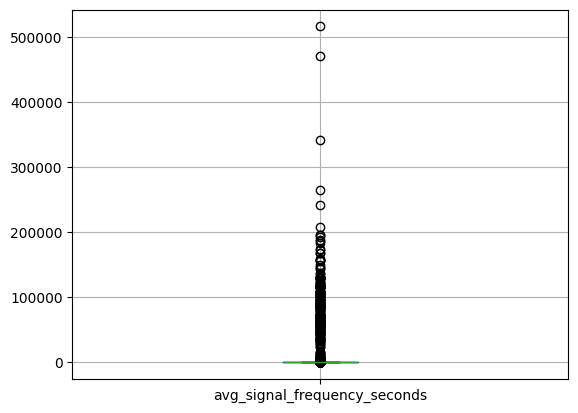

In [160]:
all_taxis.boxplot(column="avg_signal_frequency_seconds")

In [173]:
all_taxis[all_taxis["avg_signal_frequency_seconds"]<=60]

,taxi_id,avg_signal_frequency_seconds,gap_threshold_seconds,num_duplicate_timestamps,num_faulty_points
1,10,11.497056,39.0,433,57
167,10149,47.605777,150.0,1544,10
178,10159,49.602507,153.0,803,4
218,10195,56.136721,180.0,258,8
237,10211,56.059129,180.0,245,12
...,...,...,...,...,...
10279,9948,31.483326,90.0,1277,33
10280,9949,31.523847,90.0,1381,38
10281,995,51.144559,153.0,2330,2
10282,9950,31.551990,90.0,1281,36


In [170]:
all_taxis[all_taxis["avg_signal_frequency_seconds"]>=400]

,taxi_id,avg_signal_frequency_seconds,gap_threshold_seconds,num_duplicate_timestamps,num_faulty_points
0,1,633.187614,1800.0,48,0
8,10004,62662.857143,187554.0,0,0
182,10162,591.875581,1629.0,70,2
191,10170,644.385449,1800.0,57,3
193,10172,69079.600000,258417.0,0,0
...,...,...,...,...,...
10225,99,579.120585,1800.0,70,2
10301,9968,118067.000000,260949.0,2,0
10305,9971,69565.333333,260970.0,4,0
10319,9984,103180.333333,260946.0,0,0


In [174]:
10336 - 698 - 1263

8375

In [120]:
all_taxis[all_taxis["avg_signal_frequency_seconds"].isna()]

,taxi_id,avg_signal_frequency_seconds,gap_threshold_seconds,num_duplicate_timestamps,num_faulty_points
269,10240,NaN,NaN,0,0
291,10260,NaN,NaN,0,0
295,10264,NaN,NaN,0,0
663,1276,NaN,NaN,0,0
2031,2509,NaN,NaN,0,0
2768,3177,NaN,NaN,9,0
2841,3243,NaN,NaN,0,0
3288,3646,NaN,NaN,2,0
3401,3748,NaN,NaN,2,0
3960,4251,NaN,NaN,0,0


In [137]:
all_taxis[all_taxis["num_duplicate_timestamps"] > 1000]

,taxi_id,avg_signal_frequency_seconds,gap_threshold_seconds,num_duplicate_timestamps,num_faulty_points
167,10149,47.605777,150.0,1544,10
199,10178,86.539879,243.0,1061,8
216,10193,86.153071,240.0,1173,6
221,10198,90.040519,255.0,1098,1
225,10200,97.934570,273.0,1054,4
...,...,...,...,...,...
10280,9949,31.523847,90.0,1381,38
10281,995,51.144559,153.0,2330,2
10282,9950,31.551990,90.0,1281,36
10284,9952,31.466282,90.0,1181,44


In [146]:
all_taxis.sort_values(by="num_faulty_points", ascending=False)

,taxi_id,avg_signal_frequency_seconds,gap_threshold_seconds,num_duplicate_timestamps,num_faulty_points
8732,8554,5.352533,15.0,3583,18689
1729,2237,5.307037,15.0,4128,10080
2591,3015,1.164083,3.0,11666,769
6277,6340,339.605605,900.0,136,756
4659,4881,225.899522,894.0,260,746
...,...,...,...,...,...
4246,4509,167.746488,567.0,379,0
7989,7884,566.021640,1800.0,58,0
4243,4506,224.690769,751.5,309,0
4236,450,340.774775,906.0,207,0


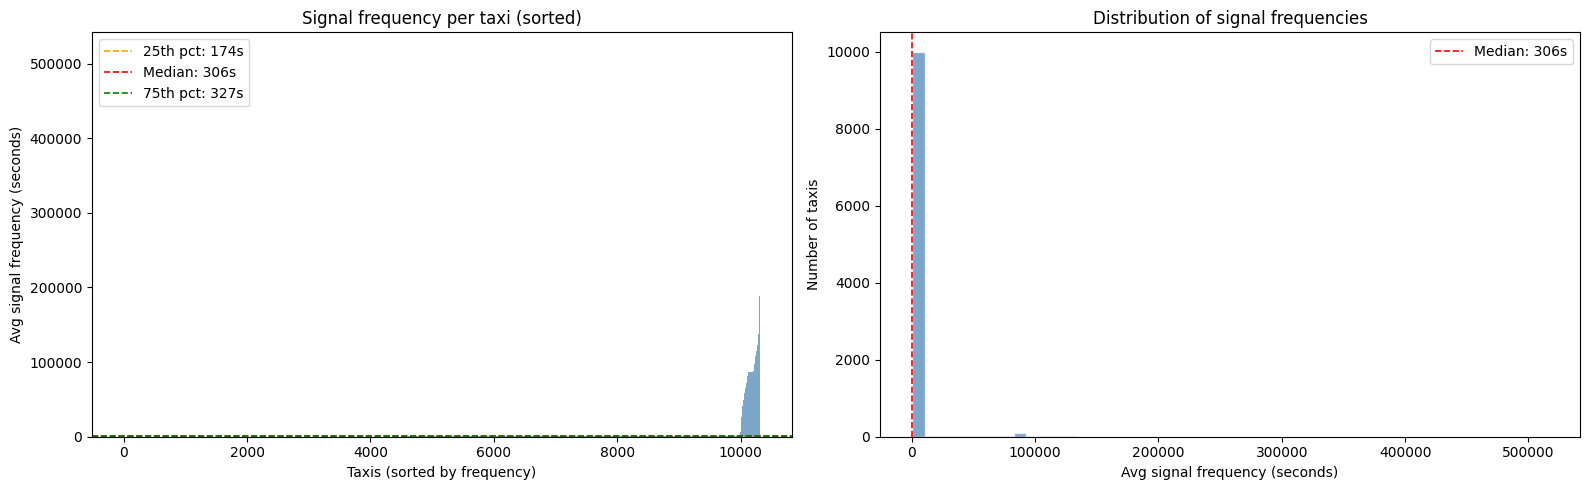


Summary statistics:
count     10316.00
mean       3033.54
std       17918.73
min           1.12
25%         173.90
50%         305.93
75%         326.75
max      516034.00
Name: avg_signal_frequency_seconds, dtype: float64


In [169]:
freqs = all_taxis["avg_signal_frequency_seconds"].dropna().sort_values().reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: sorted bar chart (one bar per taxi) ---
axes[0].bar(range(len(freqs)), freqs.values, width=1.0, color="steelblue", alpha=0.7)
axes[0].set_xlabel("Taxis (sorted by frequency)")
axes[0].set_ylabel("Avg signal frequency (seconds)")
axes[0].set_title("Signal frequency per taxi (sorted)")

# Add percentile lines
for p, color, label in [(25, "orange", "25th pct"), 
                            (50, "red",    "Median"), 
                            (75, "green",  "75th pct")]:
    val = np.percentile(freqs, p)
    axes[0].axhline(val, color=color, linestyle="--", linewidth=1.2, label=f"{label}: {val:.0f}s")
axes[0].legend()

# --- Right: histogram (how many taxis fall into each frequency bucket) ---
axes[1].hist(freqs.values, bins=50, color="steelblue", alpha=0.7, edgecolor="white")
axes[1].set_xlabel("Avg signal frequency (seconds)")
axes[1].set_ylabel("Number of taxis")
axes[1].set_title("Distribution of signal frequencies")
axes[1].axvline(freqs.median(), color="red", linestyle="--", linewidth=1.2,
                label=f"Median: {freqs.median():.0f}s")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\nSummary statistics:\n{freqs.describe().round(2)}")

# Outlier analysis

In [162]:
df = pd.DataFrame()
txt_files = [os.path.join(data_dir, "10262.txt")]

for file in tqdm(txt_files):
    with open(file, encoding="utf-8", errors="replace") as fh:
        for line in fh:
            temp = {}
            line = line.strip()
            if not line:
                continue
            parts = line.split(",")
            if len(parts) != 4:
                print("Skipping malformed line in %s: %r", os.path, line)
                continue
            taxi_id_str, ts_str, lon_str, lat_str = parts
            temp["taxi_id_str"] = [taxi_id_str]
            temp["ts_str"] = [ts_str]
            temp["lon_str"] = [lon_str]
            temp["lat_str"] = [lat_str]
            temp = pd.DataFrame.from_dict(temp)
            df = pd.concat([temp, df])

100%|██████████| 1/1 [00:00<00:00, 242.21it/s]


In [149]:
df["ts_str"] = pd.to_datetime(df["ts_str"], format="%Y-%m-%d %H:%M:%S")
df["unix_time"] = df["ts_str"].astype("int64") // 10**6
#df = df.drop_duplicates(subset=["taxi_id_str", "unix_time"], keep="first").reset_index(drop=True)

In [106]:
df["unix_time"].info()

<class 'pandas.Series'>
Index: 2 entries, 0 to 0
Series name: unix_time
Non-Null Count  Dtype
--------------  -----
2 non-null      int64
dtypes: int64(1)
memory usage: 32.0 bytes


In [163]:
df

,taxi_id_str,ts_str,lon_str,lat_str
0,10262,2008-02-08 03:35:23,116.45973,39.98512
0,10262,2008-02-07 03:25:44,116.55379,39.91884
0,10262,2008-02-05 03:06:22,116.45972,39.98503


In [150]:
duplicates = df[df.duplicated(subset="unix_time", keep=False)]
duplicates

,taxi_id_str,ts_str,lon_str,lat_str,unix_time
0,4881,2008-02-08 16:21:57,116.5804,40.07579,1202487717
0,4881,2008-02-08 16:21:57,116.5804,40.07579,1202487717
0,4881,2008-02-08 12:23:59,116.36258,39.86546,1202473439
0,4881,2008-02-08 12:23:59,116.36258,39.86546,1202473439
0,4881,2008-02-08 12:20:14,116.04795,40.41899,1202473214
...,...,...,...,...,...
0,4881,2008-02-02 13:45:32,116.34176,40.02009,1201959932
0,4881,2008-02-02 13:45:32,116.34176,40.02009,1201959932
0,4881,2008-02-02 13:45:32,116.34176,40.02009,1201959932
0,4881,2008-02-02 13:43:03,116.34183,40.02005,1201959783


In [151]:
df = df.drop_duplicates(subset=["taxi_id_str", "unix_time"], keep="first").reset_index(drop=True)

In [152]:
def get_average_trip_duration(df, gap_threshold_seconds=300, max_speed_kmh=100):
    df = df.sort_values("unix_time").reset_index(drop=True)
    df["lon"] = df["lon_str"].astype(float)
    df["lat"] = df["lat_str"].astype(float)

    trips = []
    faulty_points = []  # collect suspicious GPS jumps here

    trip_start     = df.loc[0, "unix_time"]
    prev_time      = df.loc[0, "unix_time"]
    prev_lat       = df.loc[0, "lat"]
    prev_lon       = df.loc[0, "lon"]
    trip_distance  = 0.0
    trip_coords    = [(df.loc[0, "lat"], df.loc[0, "lon"])]  # collect coords per trip

    for i in range(1, len(df)):
        curr_time = df.loc[i, "unix_time"]
        curr_lat  = df.loc[i, "lat"]
        curr_lon  = df.loc[i, "lon"]
        diff_seconds = curr_time - prev_time

        dist = haversine(prev_lat, prev_lon, curr_lat, curr_lon)

        # --- Check for implausible jumps ---
        if diff_seconds > 0:
            implied_speed_kmh = (dist / diff_seconds) * 3600
            if implied_speed_kmh > max_speed_kmh:
                faulty_points.append({
                    "index":             i,
                    "prev_lat":          prev_lat,
                    "prev_lon":          prev_lon,
                    "curr_lat":          curr_lat,
                    "curr_lon":          curr_lon,
                    "distance_km":       dist,
                    "diff_seconds":      diff_seconds,
                    "implied_speed_kmh": implied_speed_kmh,
                    "unix_time":         curr_time,
                })

        trip_distance += dist
        trip_coords.append((curr_lat, curr_lon))

        if diff_seconds > gap_threshold_seconds:
            trip_duration = prev_time - trip_start
            trips.append({
                "trip_start":       trip_start,
                "trip_end":         prev_time,
                "duration_seconds": trip_duration,
                "duration_minutes": trip_duration / 60,
                "distance_km":      trip_distance,
                "coords":           trip_coords        # store coords
            })
            trip_start    = curr_time
            trip_distance = 0.0
            trip_coords   = [(curr_lat, curr_lon)]     # reset with first point of new trip

        prev_time = curr_time
        prev_lat  = curr_lat
        prev_lon  = curr_lon

    # Last trip
    trip_duration = prev_time - trip_start
    trips.append({
        "trip_start":       trip_start,
        "trip_end":         prev_time,
        "duration_seconds": trip_duration,
        "duration_minutes": trip_duration / 60,
        "distance_km":      trip_distance,
        "coords":           trip_coords
    })

    trips_df = pd.DataFrame(trips)
    # Keep all trips including distance ~0 (breaks), only drop duration == 0
    trips_df = trips_df[trips_df["duration_seconds"] > 0]

    faulty_df = pd.DataFrame(faulty_points)

    avg_duration_minutes = trips_df["duration_minutes"].mean()
    avg_distance_km      = trips_df["distance_km"].mean()

    print(f"Number of trips found:   {len(trips_df)}")
    print(f"Average trip duration:   {avg_duration_minutes:.1f} minutes")
    print(f"Average trip distance:   {avg_distance_km:.2f} km")
    print(f"Faulty GPS points found: {len(faulty_df)}")

    return avg_duration_minutes, avg_distance_km, trips_df, faulty_df

In [93]:
def get_trips_all_taxis(df, gap_threshold_seconds=300):
    all_trips  = []
    summary    = []

    for taxi_id, taxi_df in df.groupby("taxi_id_str"):
        taxi_df = taxi_df.reset_index(drop=True)
        print(f"\n--- Taxi {taxi_id} ---")
        avg_duration, avg_distance, trips_df, faulty_df = get_average_trip_duration(
            taxi_df, gap_threshold_seconds=gap_threshold_seconds
        )
        trips_df["taxi_id_str"] = taxi_id  # tag each trip with its taxi
        all_trips.append(trips_df)
        summary.append({
            "taxi_id":             taxi_id,
            "avg_duration_minutes": avg_duration,
            "avg_distance_km":      avg_distance,
            "faulty_coords": faulty_df,
        })

    all_trips_df = pd.concat(all_trips).reset_index(drop=True)
    summary_df   = pd.DataFrame(summary)

    return all_trips_df, summary_df

In [154]:
all_trips_df, summary_df = get_trips_all_taxis(df, gap_threshold_seconds=900)


--- Taxi 4881 ---
Number of trips found:   31
Average trip duration:   255.8 minutes
Average trip distance:   560.78 km
Faulty GPS points found: 775


In [155]:
summary_df["faulty_coords"][0]

,index,prev_lat,prev_lon,curr_lat,curr_lon,distance_km,diff_seconds,implied_speed_kmh,unix_time
0,2,39.88219,116.33026,40.02005,116.34183,15.361026,43,1286.039351,1201959783
1,74,39.86225,116.35849,40.01999,116.34163,17.598685,129,491.126090,1201990417
2,75,40.01999,116.34163,39.86223,116.35847,17.600762,171,370.542362,1201990588
3,206,39.86583,116.35987,40.02007,116.34192,17.218838,203,305.358711,1202034588
4,207,40.02007,116.34192,39.86577,116.35968,17.224052,97,639.243182,1202034685
...,...,...,...,...,...,...,...,...,...
770,2091,40.41797,116.04795,39.86576,116.35973,66.878049,101,2383.772038,1202472839
771,2092,39.86576,116.35973,40.41904,116.04789,66.989238,68,3546.489092,1202472907
772,2093,40.41904,116.04789,39.86571,116.35974,66.994685,232,1039.572692,1202473139
773,2094,39.86571,116.35974,40.41899,116.04795,66.987565,75,3215.403098,1202473214


In [157]:
all_trips_df

,trip_start,trip_end,duration_seconds,duration_minutes,distance_km,coords,taxi_id_str
0,1201959523,1201960790,1267,21.116667,29.657572,"[(39.88111, 116.33024), (39.88219, 116.33026),...",4881
1,1201962123,1201962723,600,10.000000,4.569030,"[(39.90725, 116.32945), (39.91259, 116.33139),...",4881
2,1201966791,1201967623,832,13.866667,8.230697,"[(39.92765, 116.30434), (39.93691, 116.32512),...",4881
3,1201970462,1202039517,69055,1150.916667,103.339073,"[(39.90416, 116.35133), (39.90415, 116.35597),...",4881
4,1202042078,1202042378,300,5.000000,2.722113,"[(39.92177, 116.33811), (39.91329, 116.33324),...",4881
5,1202043595,1202044195,600,10.000000,8.862911,"[(39.92537, 116.3453), (39.92202, 116.3469), (...",4881
6,1202046074,1202049744,3670,61.166667,17.082108,"[(39.92559, 116.43676), (39.92303, 116.42051),...",4881
7,1202050986,1202051251,265,4.416667,6.812639,"[(39.90637, 116.33808), (39.90828, 116.33838),...",4881
8,1202054413,1202055202,789,13.150000,9.149958,"[(39.91276, 116.36281), (39.90667, 116.34647),...",4881
9,1202056543,1202143167,86624,1443.733333,3780.282554,"[(39.90683, 116.42411), (39.89919, 116.42904),...",4881


In [99]:
def plot_trips_on_map(trips_df):
    trips_df = trips_df.reset_index(drop=True)  # fix index gaps
    
    all_coords = [coord for coords in trips_df["coords"] for coord in coords]
    map_centre = [
        np.mean([c[0] for c in all_coords]),
        np.mean([c[1] for c in all_coords])
    ]
    m = folium.Map(location=map_centre, zoom_start=13)

    durations      = trips_df["duration_minutes"].values
    norm_durations = (durations - durations.min()) / (durations.max() - durations.min() + 1e-9)
    cmap           = colormaps["RdYlBu_r"]

    for i, row in trips_df.iterrows():  # i now matches norm_durations index cleanly
        color        = to_hex(cmap(norm_durations[i]))
        duration_min = row["duration_minutes"]
        distance_km  = row["distance_km"]
        coords       = row["coords"]

        if distance_km < 1:
            folium.CircleMarker(
                location=coords[0],
                radius=6,
                color=color,
                fill=True,
                fill_opacity=0.8,
                tooltip=f"Break — {duration_min:.1f} min, {distance_km:.3f} km"
            ).add_to(m)
        else:
            folium.PolyLine(
                locations=coords,
                color=color,
                weight=4,
                opacity=0.8,
                tooltip=f"Trip {i + 1}: {duration_min:.1f} min, {distance_km:.2f} km"
            ).add_to(m)

    legend_html = """
    <div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
                background-color: white; padding: 10px; border-radius: 8px;
                box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-size: 13px;">
        <b>Trip Duration</b><br>
        <span style="color:#4575b4;">&#9644;</span> Short<br>
        <span style="color:#fee090;">&#9644;</span> Medium<br>
        <span style="color:#d73027;">&#9644;</span> Long<br><br>
        <b>&#9711;</b> Stationary break
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    output_path = "trips_map.html"
    m.save(output_path)
    print(f"Map saved to {output_path}")
    return m

In [13]:
trips.index

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 40, 41, 43, 44],
      dtype='int64')

In [156]:
m = plot_trips_on_map(all_trips_df)

Map saved to trips_map.html


Keep in mind:
- some trip times include the time the taxi has been on stand by and then become much longer -> we need to make sure to filter out those parts
- also keep i nmind that locations are only send every 10 seconds -> quite large jumps on the map
- sometimes for one timestamp two identical messages are being send -> results in two same timestamps -> check how this is handled in our application
- some taxis send every 10 minutes (!!) and some send every 30 to 60 seconds or less -> need to be adaptive in how often we send data to back/frontend

Maybe add these features to our dashboard:
- Identify when a taxi starts a new trip
- avergae trip duration in dashboard
- average trip length in dashboard
- no don't care about trips, since it is too difficult to distinguis one trip from another
- maybe interesting for later database analysis?